# Variant effect prediction with ESM-2


In [1]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import esm

from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr

## 1. Loading and preparing data:

#### Load binding data for GRB-2 dataset (data downlaoed from: https://github.com/gitter-lab/metl-pub/blob/main/data/dms_data/grb2-binding/grb2-binding.tsv)

In [2]:
df = pd.read_csv("./data/grb2_binding.tsv", sep="\t")
df.head()

,variant,num_mutations,score,sequence
0,T158A,1,0.010567,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...
1,T158C,1,0.020651,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...
2,T158D,1,0.105938,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...
3,T158E,1,-0.001826,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...
4,T158F,1,0.026470,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...


In [3]:
df["sequence"].loc[0][158]

'A'

#### Sample 1000 single and 1000 double mutants

In [4]:
single = df[df["num_mutations"] == 1]
double = df[df["num_mutations"] == 2]

if len(single) < 1000 or len(double) < 1000:
    raise ValueError(
        f"Not enough data to sample 1000 from each class. single={len(single)}, double={len(double)}"
    )

single_sample = single.sample(n=1000, random_state=42)
double_sample = double.sample(n=1000, random_state=42)

sampled = pd.concat(
    [
        single_sample.assign(mutation_class="single"),
        double_sample.assign(mutation_class="double"),
    ],
    ignore_index=True,
)

sampled.groupby("mutation_class")["score"].describe()

,count,mean,std,min,25%,50%,75%,max
mutation_class,,,,,,,,
double,1000.0,-0.782872,0.476296,-1.654505,-1.165661,-0.956763,-0.396232,0.516285
single,1000.0,-0.426496,0.449147,-1.234026,-0.913403,-0.247962,-0.034146,0.292170


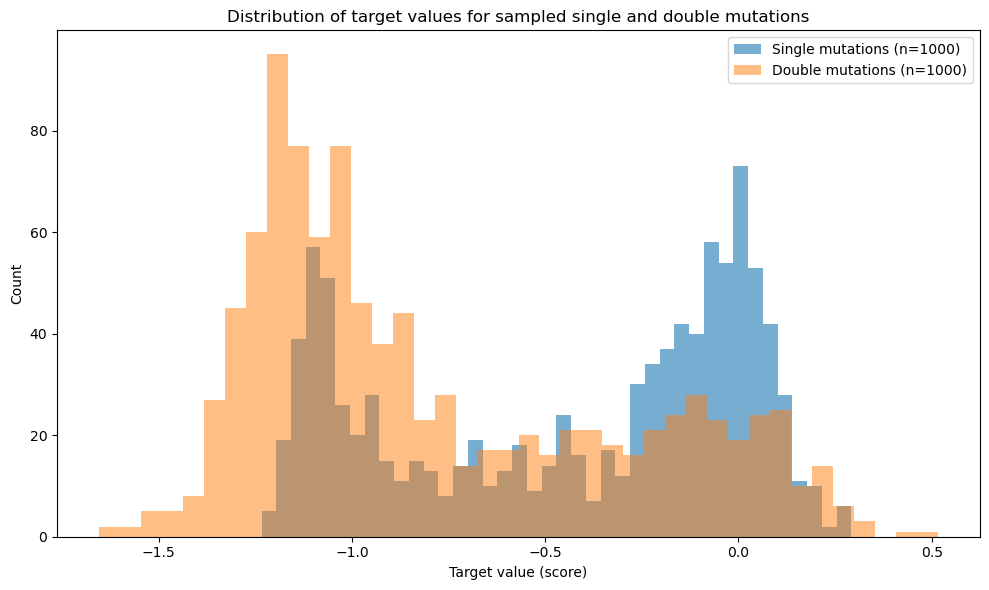

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bins = 40

plt.hist(single_sample["score"], bins=bins, alpha=0.6, label="Single mutations (n=1000)")
plt.hist(double_sample["score"], bins=bins, alpha=0.5, label="Double mutations (n=1000)")

plt.xlabel("Target value (score)")
plt.ylabel("Count")
plt.title("Distribution of target values for sampled single and double mutations")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Zero-Shot prediction of mutation effects:

#### Loading ESM-2 model in evaluation mode:

In [6]:
model_name: str = "esm2_t30_150M_UR50D"
model, alphabet = getattr(esm.pretrained, model_name)()
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
batch_converter = alphabet.get_batch_converter()

In [7]:
tok_to_idx = alphabet.tok_to_idx
idx_to_tok = {idx: tok for tok, idx in tok_to_idx.items()}
idx_to_tok

{0: '<cls>',
 1: '<pad>',
 2: '<eos>',
 3: '<unk>',
 4: 'L',
 5: 'A',
 6: 'G',
 7: 'V',
 8: 'S',
 9: 'E',
 10: 'R',
 11: 'T',
 12: 'I',
 13: 'D',
 14: 'P',
 15: 'K',
 16: 'Q',
 17: 'N',
 18: 'F',
 19: 'Y',
 20: 'M',
 21: 'H',
 22: 'W',
 23: 'C',
 24: 'X',
 25: 'B',
 26: 'U',
 27: 'Z',
 28: 'O',
 29: '.',
 30: '-',
 31: '<null_1>',
 32: '<mask>'}

#### Masking positions

In [8]:
sequence = "MKMALWOL"

data = [("seq", sequence)]
_, _, tokens = batch_converter(data)
tokens = tokens.to(device)

print(f"Sequence: {sequence}")
print(f"Tokens: {tokens}\n")


print(f"Masking token ID: {alphabet.mask_idx}")
print(f"CLS token index: {alphabet.cls_idx}")
print(f"EOS token index: {alphabet.eos_idx}\n")

mask_positions_0based = 0

masked_tokens = tokens.clone()
masked_tokens[0, mask_positions_0based + 1] = alphabet.mask_idx 
print(tokens[0])
print(masked_tokens[0])

Sequence: MKMALWOL
Tokens: tensor([[ 0, 20, 15, 20,  5,  4, 22, 28,  4,  2]])

Masking token ID: 32
CLS token index: 0
EOS token index: 2

tensor([ 0, 20, 15, 20,  5,  4, 22, 28,  4,  2])
tensor([ 0, 32, 15, 20,  5,  4, 22, 28,  4,  2])


#### predict amino acid probabilities

In [9]:
with torch.no_grad():
    out = model(masked_tokens, repr_layers=[], return_contacts=False)
    # out["logits"] has shape [B, L, V]
    logits = out["logits"][0]  # [L, V] for the single sequence in the batch

print(logits.shape)

logits

torch.Size([10, 33])


tensor([[ 1.3125e+01, -7.8092e+00, -8.6750e-01, -7.7080e+00, -1.2339e-01,
          3.3088e-01, -2.6612e-02, -3.2238e-02, -2.1910e-01, -1.0977e-01,
         -6.0950e-02, -9.6323e-01, -3.1372e-01, -1.4368e+00, -2.9472e-02,
          3.6681e-01, -7.5409e-01, -8.8470e-01, -9.0993e-01, -1.7176e+00,
          3.4864e+00, -1.7791e+00, -1.9474e+00, -1.5381e+00, -5.6116e-01,
         -7.0579e+00, -9.8707e+00, -8.2599e+00, -1.5631e+01, -1.5666e+01,
         -1.4906e+01, -1.6542e+01, -7.7626e+00],
        [-9.2151e+00, -1.3970e+01, -8.8797e+00, -1.3975e+01,  7.8664e-01,
         -1.5467e-01, -1.4011e-01,  2.4671e-01, -7.5397e-02, -1.8779e-01,
         -1.2395e-01, -4.6529e-01, -1.9879e-01, -1.0589e+00, -5.1794e-01,
          2.0024e-01, -4.1712e-01, -8.6652e-01, -6.4628e-01, -1.0333e+00,
          4.0090e+00, -1.3274e+00, -9.3111e-01, -1.1200e+00, -1.0083e+00,
         -8.6712e+00, -9.6292e+00, -9.8392e+00, -1.5430e+01, -1.5534e+01,
         -1.5273e+01, -1.6109e+01, -1.3975e+01],
        [-1.04

In [10]:
pos = 0
raw_logits = logits[pos+1]
predicted_probabilities = torch.softmax(raw_logits, dim =-1)
print(torch.round(predicted_probabilities, decimals=2))

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0300, 0.0100, 0.0100, 0.0200, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0000, 0.0100, 0.0200, 0.0100, 0.0100,
        0.0100, 0.0100, 0.7900, 0.0000, 0.0100, 0.0000, 0.0100, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])


In [11]:
for aa in alphabet.standard_toks:
    print(f"  {aa}: {predicted_probabilities[tok_to_idx[aa]]*100:.1f}%")

  L: 3.1%
  A: 1.2%
  G: 1.2%
  V: 1.8%
  S: 1.3%
  E: 1.2%
  R: 1.3%
  T: 0.9%
  I: 1.2%
  D: 0.5%
  P: 0.9%
  K: 1.7%
  Q: 0.9%
  N: 0.6%
  F: 0.8%
  Y: 0.5%
  M: 78.9%
  H: 0.4%
  W: 0.6%
  C: 0.5%
  X: 0.5%
  B: 0.0%
  U: 0.0%
  Z: 0.0%
  O: 0.0%
  .: 0.0%
  -: 0.0%


#### Compute log proability score

In [12]:
pos = 0
wt_AA = "M"
mut_AA = "K"

raw_logits = logits[pos+1]
predicted_probabilities = torch.softmax(raw_logits, dim =-1)

prob_wt = predicted_probabilities[tok_to_idx[wt_AA]]
prob_mut = predicted_probabilities[tok_to_idx[mut_AA]]

log_prob_score = torch.log(prob_mut / prob_wt).item()
print(f"Log-probability score: {log_prob_score:.2f}")

Log-probability score: -3.81


### Comput log-probability scores for the GRB-2 dataset:

In [13]:
ind = 1995
sequence = df["sequence"].loc[ind]
variant = df["variant"].loc[ind]

mutations = variant.split(",")


wt_AAs, mut_AAs, mut_pos = [], [], []
for mut in mutations:
    wt_AAs.append(mut[0]), mut_AAs.append(mut[-1]), mut_pos.append(int(mut[1:-1]))


_, _, tokens = batch_converter([("seq", sequence)])


log_prob_score = 0
for wt_AA, mut_AA, pos in zip(wt_AAs, mut_AAs,mut_pos):
    masked_tokens = tokens.to(device).clone()
    masked_tokens[0, pos + 1] = alphabet.mask_idx 
    with torch.no_grad():
        logits = model(masked_tokens, repr_layers=[], return_contacts=False)["logits"][0]
    predicted_probabilities = torch.softmax(logits[pos+1], dim =-1)
    prob_wt = predicted_probabilities[tok_to_idx[wt_AA]]
    prob_mut = predicted_probabilities[tok_to_idx[mut_AA]]

    log_prob_score += torch.log(prob_mut / prob_wt).item()

    print(f"Position: {pos}, Mutation: {wt_AA} -> {mut_AA},  Log Prob. Score:{torch.log(prob_mut / prob_wt).item()}")

print(f"\nVariant: {variant}, Log Prob. Score: {log_prob_score}")


Position: 158, Mutation: T -> R,  Log Prob. Score:-0.16128374636173248
Position: 189, Mutation: D -> E,  Log Prob. Score:-3.6098551750183105

Variant: T158R,D189E, Log Prob. Score: -3.771138921380043


In [14]:
def score_variant(sequence, variant):
    log_prob_score = 0.0

    for m in variant.split(","):
        wt_AA, mut_AA = m[0], m[-1]
        pos0 = int(m[1:-1])  

        _, _, tokens = batch_converter([("seq", sequence)])
        masked_tokens = tokens.to(device).clone()
        masked_tokens[0, pos0 + 1] = alphabet.mask_idx  # +1 only for CLS offset

        with torch.no_grad():
            logits = model(masked_tokens, repr_layers=[], return_contacts=False)["logits"][0, pos0 + 1]

        probs = torch.softmax(logits, dim=-1)
        log_prob_score += torch.log(probs[tok_to_idx[mut_AA]] / probs[tok_to_idx[wt_AA]]).item()

    return log_prob_score

sampled["ESM2_score"] = np.nan

for ind in tqdm(range(len(sampled)), desc="Scoring variants"):
    sampled.loc[ind, "ESM2_score"] = score_variant(
        sampled.loc[ind, "sequence"],
        sampled.loc[ind, "variant"]
    )

Scoring variants: 100%|██████████| 2000/2000 [13:14<00:00,  2.52it/s]


In [15]:
sampled.to_csv("sampled.csv")

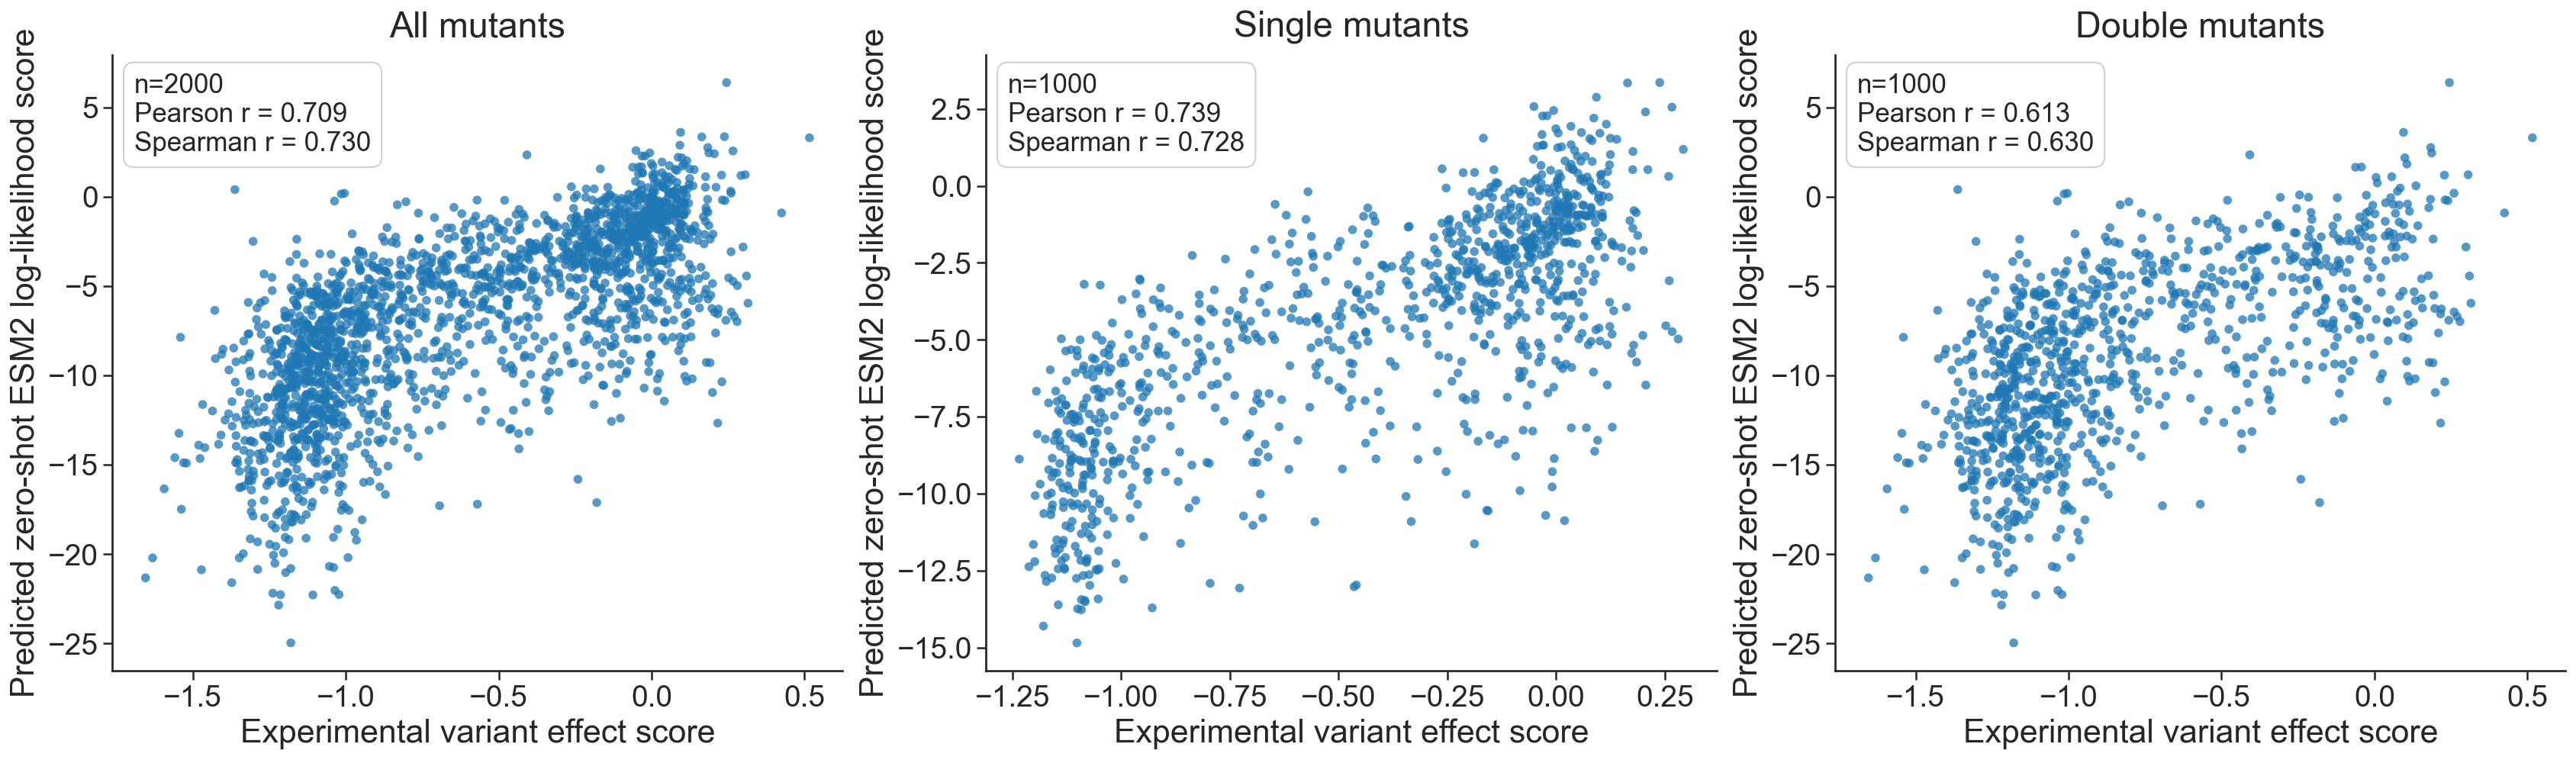

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,
})

def scatter_with_stats(ax, df, title):
    d = df[["score", "ESM2_score"]].dropna()
    x = d["score"].values
    y = d["ESM2_score"].values

    ax.scatter(x, y, s=36, alpha=0.75, color="#1f77b4", edgecolors="none")
    ax.set_title(title, pad=12)
    ax.set_xlabel("Experimental variant effect score")
    ax.set_ylabel("Predicted zero-shot ESM2 log-likelihood score")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)
    ax.tick_params(direction="out", length=6, width=1.3)

    if len(d) >= 2:
        r, _ = pearsonr(x, y)
        rho, _ = spearmanr(x, y)
        txt = f"n={len(d)}\nPearson r = {r:.3f}\nSpearman r = {rho:.3f}"
    else:
        txt = f"n={len(d)}\nPearson r = nan\nSpearman r = nan"

    ax.text(
        0.03, 0.97, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=18,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.8", alpha=0.95)
    )

# main 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(24, 7), dpi=140, constrained_layout=True)
scatter_with_stats(axes[0], sampled, "All mutants")
scatter_with_stats(axes[1], sampled[sampled["num_mutations"] == 1], "Single mutants")
scatter_with_stats(axes[2], sampled[sampled["num_mutations"] == 2], "Double mutants")
plt.show()






## 3. Finetuning ESM-2 for variant effect prediction

#### Preparing data

In [17]:
sampled = pd.read_csv("sampled.csv")
sampled

,Unnamed: 0,variant,num_mutations,score,sequence,mutation_class,ESM2_score
0,0,L174Q,1,-0.636886,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,single,-7.823896
1,1,H183A,1,0.002486,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,single,-0.682089
2,2,W193C,1,-0.522774,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,single,-6.321951
3,3,F166I,1,-0.684383,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,single,-8.645090
4,4,N187P,1,-0.497644,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,single,-4.042399
...,...,...,...,...,...,...,...
1995,1995,"P168C,N207E",2,-0.332249,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,double,-9.825006
1996,1996,"M185T,K194P",2,-0.878866,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,double,-5.068114
1997,1997,"R178M,C197R",2,-0.872013,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,double,-4.133446
1998,1998,"V160G,M185F",2,-1.156356,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,double,-5.566487


In [18]:
sampled_sequences = sampled["sequence"]
sampled_y = sampled["score"]

#Split randomly in train, val and test:
from sklearn.model_selection import train_test_split

train_sequences, test_sequences, train_y, test_y = train_test_split(sampled_sequences,
                                                                    sampled_y,
                                                                    test_size=0.2,
                                                                    random_state=42)

train_sequences, val_sequences, train_y, val_y = train_test_split(train_sequences,
                                                                  train_y,
                                                                  test_size=0.25,
                                                                  random_state=42)

train_size = len(train_sequences)
val_size = len(val_sequences)
test_size = len(test_sequences)

print(f"Training: {train_size}, Validation: {val_size}, Test: {test_size}")


Training: 1200, Validation: 400, Test: 400


In [19]:
from torch.utils.data import Dataset, DataLoader

batch_size = 4


class ESM2Dataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences.iloc[idx], self.labels.iloc[idx]

train_dataset = ESM2Dataset(train_sequences, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = ESM2Dataset(val_sequences, val_y)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = ESM2Dataset(test_sequences, test_y)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### Load and define model

In [20]:
device = "cpu"
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D() #esm.pretrained.esm2_t33_650M_UR50D
batch_converter = alphabet.get_batch_converter()
model.train();
last_layer = len(model.layers)
emb_dim = model.embed_dim

hidden_dim_MLP = 128
lr =  1e-5
num_epochs = 10


In [21]:
class ESM_FFN(torch.nn.Module):
    def __init__(self, esm2_model, emb_dim, hidden_dim, last_layer):
        super(ESM_FFN, self).__init__()
        self.last_layer = last_layer
        self.esm2_model = esm2_model
        self.relu = torch.nn.ReLU()

        self.MLP = torch.nn.Sequential(
            torch.nn.Linear(emb_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, batch_tokens):
        results = self.esm2_model(batch_tokens, repr_layers=[self.last_layer], return_contacts=False)
        cls_repr = results["representations"][self.last_layer][:, 0, :]
        y = self.MLP(cls_repr)
        return y
    
    #Optional (only if you need cls embeddings after fine-tuning):
    def extract_representation(self, batch_tokens):
        results = self.esm2_model(batch_tokens, repr_layers=[self.last_layer], return_contacts=False)
        cls_repr = results["representations"][self.last_layer][:, 0, :]
        return cls_repr

In [22]:
full_model = ESM_FFN(model, emb_dim = emb_dim, hidden_dim = hidden_dim_MLP, last_layer = last_layer).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(full_model.parameters(), lr=lr)

In [23]:
for epoch in range(1, num_epochs+1):
    train_losses = []
    full_model.train()
    #Training loop
    with tqdm(total=len(train_loader), desc=f"Epoch {epoch}") as pbar:
        for batch_seqs, labels in train_loader:
            batch_seq_tuples = [("seq %d" % i, seq) for i, seq in enumerate(batch_seqs)]
            batch_labels, batch_strs, batch_tokens = batch_converter(batch_seq_tuples)

            batch_y_tensor = labels.float().to(device)
            batch_tokens = batch_tokens.to(device)

            optimizer.zero_grad()
            output = full_model(batch_tokens)
            loss = criterion(output.view(-1), batch_y_tensor.view(-1))
            loss.backward()
            optimizer.step()

            # tracking
            train_losses.append(float(loss.item()))
            pbar.set_postfix({"Train Loss": f"{np.mean(train_losses):.3f}"})
            pbar.update(1)

    print("Epoch: %d, Training Loss: %.3f" % (epoch, np.mean(train_losses)))
    
    #Validation loop
    val_true, val_pred = [], []
    full_model.eval()
    for batch_seqs, labels in val_loader:
        batch_seq_tuples = [("seq %d" % i, seq) for i, seq in enumerate(batch_seqs)]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch_seq_tuples)
        batch_y_tensor = labels.float().to(device)

        batch_tokens = batch_tokens.to(device)
        batch_y_tensor = batch_y_tensor.to(device)
        with torch.no_grad():
            output = full_model(batch_tokens)
        val_true.extend(list(batch_y_tensor.cpu().detach().numpy()))
        val_pred.extend(list(output.cpu().detach().numpy().reshape(-1)))
        
    val_true = np.array(val_true).reshape(-1)
    val_pred = np.array(val_pred).reshape(-1)
    mse = np.mean((val_true-val_pred)**2)
    r2 = r2_score(val_true, val_pred)
    pearson_r = pearsonr(val_true, val_pred)[0]
    spearman_r = spearmanr(val_true, val_pred)[0]
    print(f"Epoch: {epoch}, Validation Loss: {mse:.3f}, R2: {r2:.3f}, "
      f"Pearson r: {pearson_r:.3f}, Spearman r: {spearman_r:.3f}")

Epoch 1: 100%|██████████| 300/300 [01:15<00:00,  3.97it/s, Train Loss=0.257]


Epoch: 1, Training Loss: 0.257
Epoch: 1, Validation Loss: 0.235, R2: 0.027, Pearson r: 0.655, Spearman r: 0.663


Epoch 2: 100%|██████████| 300/300 [01:12<00:00,  4.15it/s, Train Loss=0.223]


Epoch: 2, Training Loss: 0.223
Epoch: 2, Validation Loss: 0.181, R2: 0.253, Pearson r: 0.641, Spearman r: 0.641


Epoch 3: 100%|██████████| 300/300 [01:13<00:00,  4.08it/s, Train Loss=0.149]


...

Epoch: 8, Training Loss: 0.054
Epoch: 8, Validation Loss: 0.056, R2: 0.769, Pearson r: 0.880, Spearman r: 0.853


Epoch 9: 100%|██████████| 300/300 [01:11<00:00,  4.20it/s, Train Loss=0.051]


Epoch: 9, Training Loss: 0.051
Epoch: 9, Validation Loss: 0.057, R2: 0.764, Pearson r: 0.879, Spearman r: 0.856


Epoch 10: 100%|██████████| 300/300 [01:16<00:00,  3.92it/s, Train Loss=0.051]


Epoch: 10, Training Loss: 0.051
Epoch: 10, Validation Loss: 0.059, R2: 0.757, Pearson r: 0.873, Spearman r: 0.853


In [24]:
#Test loop
test_true, test_pred = [], []
full_model.eval()
for batch_seqs, labels in test_loader:
    batch_seq_tuples = [("seq %d" % i, seq) for i, seq in enumerate(batch_seqs)]
    batch_labels, batch_strs, batch_tokens = batch_converter(batch_seq_tuples)
    batch_y_tensor = labels.float().to(device)

    batch_tokens = batch_tokens.to(device)
    batch_y_tensor = batch_y_tensor.to(device)
    with torch.no_grad():
        output = full_model(batch_tokens)
    test_true.extend(list(batch_y_tensor.cpu().detach().numpy()))
    test_pred.extend(list(output.cpu().detach().numpy().reshape(-1)))
    

test_true = np.array(test_true).reshape(-1)
test_pred = np.array(test_pred).reshape(-1)
mse = np.mean((test_true-test_pred)**2)
r2 = r2_score(test_true, test_pred)
pearson_r = pearsonr(test_true, test_pred)[0]
spearman_r = spearmanr(test_true, test_pred)[0]
print(f"Test Loss: {mse:.3f}, R2: {r2:.3f}, "
    f"Pearson r: {pearson_r:.3f}, Spearman r: {spearman_r:.3f}")

Test Loss: 0.069, R2: 0.720, Pearson r: 0.849, Spearman r: 0.827
